In [1]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

num_samples = 3000
feat1 = np.random.uniform(-2, 2, num_samples)
feat2 = np.random.uniform(-2, 2, num_samples)
X = np.vstack([feat1, feat2]).T

# Label: 1 if the point falls outside a circle of radius sqrt(1.5), else 0
y = ((feat1 ** 2 + feat2 ** 2) > 1.5).astype(int)
y = y.reshape(-1, 1)

print(X.shape, y.shape)


(3000, 2) (3000, 1)


In [2]:
shuffled = np.random.permutation(num_samples)
tr_end = int(0.7 * num_samples)
va_end = int(0.85 * num_samples)

tr_idx  = shuffled[:tr_end]
va_idx  = shuffled[tr_end:va_end]
te_idx  = shuffled[va_end:]

X_train = X[tr_idx];  y_train = y[tr_idx]
X_val   = X[va_idx];  y_val   = y[va_idx]
X_test  = X[te_idx];  y_test  = y[te_idx]

print(X_train.shape, X_val.shape, X_test.shape)


(2100, 2) (450, 2) (450, 2)


In [3]:
def binary_cross_entropy(y_true, y_pred):
    eps = 1e-8
    y_pred = np.clip(y_pred, eps, 1 - eps)
    loss = -(y_true * np.log(y_pred) + (1 - y_true) * np.log(1 - y_pred))
    return np.mean(loss)


def classification_accuracy(y_true, y_pred):
    predicted_labels = (y_pred >= 0.5).astype(int)
    return np.mean(predicted_labels == y_true)


In [4]:
def sigmoid(z):
    z = np.clip(z, -500, 500)
    return 1 / (1 + np.exp(-z))

def sigmoid_deriv(z):
    s = sigmoid(z)
    return s * (1 - s)


def relu(z):
    return np.maximum(0, z)

def relu_deriv(z):
    return (z > 0).astype(float)


In [5]:
def build_network(layer_dims):
    params = {}
    for i in range(len(layer_dims) - 1):
        # He initialisation for ReLU-friendly scaling
        params["W" + str(i+1)] = np.random.randn(layer_dims[i], layer_dims[i+1]) * np.sqrt(2 / layer_dims[i])
        params["b" + str(i+1)] = np.zeros((1, layer_dims[i+1]))
    return params


In [6]:
def forward_pass(X, params, activation):
    cache = {}
    A = X
    depth = len(params) // 2

    for l in range(1, depth):
        Z = A @ params["W" + str(l)] + params["b" + str(l)]
        A = sigmoid(Z) if activation == "sigmoid" else relu(Z)
        cache["Z" + str(l)] = Z
        cache["A" + str(l)] = A

    # Final layer always uses sigmoid for binary classification
    Z_out = A @ params["W" + str(depth)] + params["b" + str(depth)]
    A_out = sigmoid(Z_out)
    cache["Z" + str(depth)] = Z_out
    cache["A" + str(depth)] = A_out
    return A_out, cache


In [7]:
def backprop(X, y, params, cache, activation):
    grads = {}
    depth = len(params) // 2
    m = X.shape[0]
    A_last = cache["A" + str(depth)]

    for l in reversed(range(1, depth + 1)):
        A_prev = X if l == 1 else cache["A" + str(l-1)]
        Z = cache["Z" + str(l)]

        if l == depth:
            dZ = A_last - y  # BCE + sigmoid derivative cancel nicely
        else:
            if activation == "sigmoid":
                dZ = dA * sigmoid_deriv(cache["A" + str(l)])
            else:
                dZ = dA * relu_deriv(Z)

        grads["dW" + str(l)] = A_prev.T @ dZ / m
        grads["db" + str(l)] = np.sum(dZ, axis=0, keepdims=True) / m

        # Clip gradients to prevent instability
        grads["dW" + str(l)] = np.clip(grads["dW" + str(l)], -5, 5)
        grads["db" + str(l)] = np.clip(grads["db" + str(l)], -5, 5)

        dA = dZ @ params["W" + str(l)].T

    return grads


In [8]:
def apply_sgd(params, grads, lr):
    depth = len(params) // 2
    for l in range(1, depth + 1):
        params["W" + str(l)] -= lr * grads["dW" + str(l)]
        params["b" + str(l)] -= lr * grads["db" + str(l)]


In [9]:
def apply_momentum(params, grads, velocity, lr, beta=0.9):
    depth = len(params) // 2
    for l in range(1, depth + 1):
        velocity["W" + str(l)] = beta * velocity["W" + str(l)] + lr * grads["dW" + str(l)]
        velocity["b" + str(l)] = beta * velocity["b" + str(l)] + lr * grads["db" + str(l)]
        params["W" + str(l)] -= velocity["W" + str(l)]
        params["b" + str(l)] -= velocity["b" + str(l)]


In [10]:
def train_network(X_tr, y_tr, X_va, y_va, arch, activation, optimizer, epochs=200, lr=0.01):
    params = build_network(arch)

    # Initialise velocity buffers (used only for momentum)
    velocity = {}
    for l in range(1, len(arch)):
        velocity["W" + str(l)] = np.zeros_like(params["W" + str(l)])
        velocity["b" + str(l)] = np.zeros_like(params["b" + str(l)])

    tr_losses, va_losses = [], []
    tr_accs,   va_accs   = [], []

    for ep in range(epochs):
        y_pred, cache = forward_pass(X_tr, params, activation)
        loss = binary_cross_entropy(y_tr, y_pred)
        acc  = classification_accuracy(y_tr, y_pred)
        grads = backprop(X_tr, y_tr, params, cache, activation)

        if optimizer == "sgd":
            apply_sgd(params, grads, lr)
        else:
            apply_momentum(params, grads, velocity, lr)

        y_val_pred, _ = forward_pass(X_va, params, activation)

        tr_losses.append(loss)
        va_losses.append(binary_cross_entropy(y_va, y_val_pred))
        tr_accs.append(acc)
        va_accs.append(classification_accuracy(y_va, y_val_pred))

    return params, tr_losses, va_losses, tr_accs, va_accs


In [11]:
arch_2layer  = [2, 8, 1]
arch_5layer  = [2, 8, 8, 8, 8, 1]
arch_10layer = [2, 8, 8, 8, 8, 8, 8, 8, 8, 8, 1]


In [12]:
params, train_losses, val_losses, train_accs, val_accs = train_network(
    X_train, y_train, X_val, y_val,
    arch=arch_5layer,
    activation="relu",
    optimizer="momentum",
    epochs=200
)


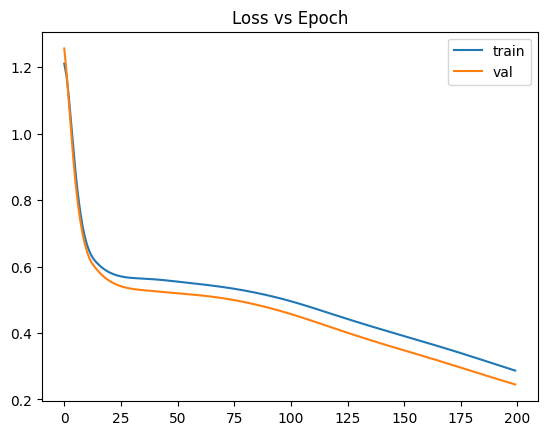

In [13]:
plt.plot(train_losses, label="train")
plt.plot(val_losses, label="val")
plt.legend()
plt.title("Loss vs Epoch")
plt.show()


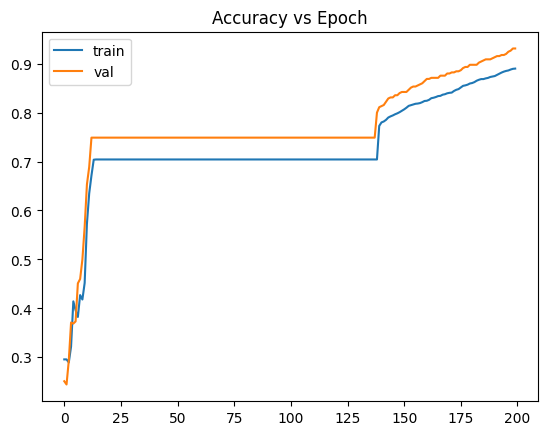

In [14]:
plt.plot(train_accs, label="train")
plt.plot(val_accs, label="val")
plt.legend()
plt.title("Accuracy vs Epoch")
plt.show()


In [15]:
test_preds, _ = forward_pass(X_test, params, "relu")

print("Test Loss:", binary_cross_entropy(y_test, test_preds))
print("Test Accuracy:", classification_accuracy(y_test, test_preds))


Test Loss: 0.2584169793245899
Test Accuracy: 0.9133333333333333


## Analysis

Does adding more layers always improve validation accuracy?
Not necessarily. Beyond a certain point, adding depth can hurt validation performance
due to vanishing gradients and overfitting rather than helping.


What happens to test accuracy as the network gets deeper?
It may improve initially but tends to drop off in very deep configurations
where gradient flow breaks down or the model memorises training data.


Do sigmoid networks deteriorate more quickly with depth?
Yes. The sigmoid derivative is bounded between 0 and 0.25, so repeated multiplication
during backprop causes gradients to vanish exponentially in deep sigmoid networks.


Does the choice of optimizer matter more for deep networks?
Yes. Momentum smooths out gradient updates and helps gradients flow more reliably
through many layers, giving it a clear advantage over plain SGD in deep architectures.


Can validation performance reliably predict test performance?
Generally yes, since the validation set is not seen during training.
However, heavy tuning against the validation set can cause it to overestimate test performance.


In [16]:
def create_image_data(n):
    images, labels = [], []

    for _ in range(n):
        canvas = np.zeros((8, 8))
        if np.random.rand() < 0.5:
            canvas[:, 4] = 1  # vertical stripe -> class 0
            lbl = 0
        else:
            canvas[4, :] = 1  # horizontal stripe -> class 1
            lbl = 1

        canvas += np.random.normal(0, 0.1, (8, 8))  # add noise
        images.append(canvas)
        labels.append(lbl)

    return np.array(images), np.array(labels).reshape(-1, 1)


In [17]:
X_imgs, y_imgs = create_image_data(3000)
print(X_imgs.shape, y_imgs.shape)


(3000, 8, 8) (3000, 1)


In [18]:
n_img = X_imgs.shape[0]
img_idx = np.random.permutation(n_img)
img_tr_end = int(0.7 * n_img)
img_va_end = int(0.85 * n_img)

img_tr_idx = img_idx[:img_tr_end]
img_va_idx = img_idx[img_tr_end:img_va_end]
img_te_idx = img_idx[img_va_end:]

X_train_img = X_imgs[img_tr_idx];  y_train_img = y_imgs[img_tr_idx]
X_val_img   = X_imgs[img_va_idx];  y_val_img   = y_imgs[img_va_idx]
X_test_img  = X_imgs[img_te_idx];  y_test_img  = y_imgs[img_te_idx]


In [19]:
# Flatten each 8x8 image to a 64-element vector for the dense network
X_train_flat = X_train_img.reshape(-1, 64)
X_val_flat   = X_val_img.reshape(-1, 64)
X_test_flat  = X_test_img.reshape(-1, 64)


In [20]:
dense_arch = [64, 32, 1]


In [21]:
params_dense, tl_dense, vl_dense, ta_dense, va_dense = train_network(
    X_train_flat,
    y_train_img,
    X_val_flat,
    y_val_img,
    arch=dense_arch,
    activation="relu",
    optimizer="momentum",
    epochs=200,
    lr=0.001
)


In [22]:
dense_test_preds, _ = forward_pass(X_test_flat, params_dense, "relu")
print("Dense Test Loss:",     binary_cross_entropy(y_test_img, dense_test_preds))
print("Dense Test Accuracy:", classification_accuracy(y_test_img, dense_test_preds))


Dense Test Loss: 0.07044000279518726
Dense Test Accuracy: 1.0


In [23]:
def apply_filter(image, kernel):
    H, W = image.shape
    k = kernel.shape[0]
    out_h = H - k + 1
    out_w = W - k + 1
    result = np.zeros((out_h, out_w))
    for i in range(out_h):
        for j in range(out_w):
            patch = image[i:i+k, j:j+k]
            result[i, j] = np.sum(patch * kernel)
    return result


In [24]:
def run_conv_layer(image, filter_bank):
    feature_maps = []
    for filt in filter_bank:
        feature_maps.append(apply_filter(image, filt))
    return np.array(feature_maps)


In [25]:
def apply_relu(x):
    return np.maximum(0, x)


In [26]:
def max_pool_2x2(feature_map):
    H, W = feature_map.shape
    pooled = np.zeros((H // 2, W // 2))
    for i in range(0, H, 2):
        for j in range(0, W, 2):
            region = feature_map[i:i+2, j:j+2]
            pooled[i//2, j//2] = np.max(region)
    return pooled


In [27]:
def run_pool_layer(feature_maps):
    pooled_maps = []
    for fmap in feature_maps:
        pooled_maps.append(max_pool_2x2(fmap))
    return np.array(pooled_maps)


In [28]:
def flatten_maps(feature_maps):
    return feature_maps.flatten().reshape(1, -1)


In [29]:
def cnn_predict(image, filter_bank, W_fc, b_fc):
    conv_out  = run_conv_layer(image, filter_bank)
    relu_out  = apply_relu(conv_out)
    pooled    = run_pool_layer(relu_out)
    flat      = flatten_maps(pooled)
    logit     = flat @ W_fc + b_fc
    y_hat     = sigmoid(logit)
    return y_hat, flat


In [30]:
n_filters    = 4
kernel_size  = 3
filter_bank  = np.random.randn(n_filters, kernel_size, kernel_size) * 0.1

# After conv (8-3+1=6) and 2x2 pooling (6//2=3): each filter gives a 3x3 map
fc_input_dim = n_filters * 3 * 3
W_fc = np.random.randn(fc_input_dim, 1) * 0.1
b_fc = np.zeros((1, 1))


In [31]:
def train_cnn_basic(X_data, y_data, num_epochs=50, lr=0.01):
    global filter_bank, W_fc, b_fc
    epoch_losses = []

    for ep in range(num_epochs):
        running_loss = 0
        for idx in range(len(X_data)):
            img   = X_data[idx]
            label = y_data[idx]
            y_hat, flat = cnn_predict(img, filter_bank, W_fc, b_fc)
            loss = binary_cross_entropy(label, y_hat)
            running_loss += loss

            # Backprop through fully-connected layer only
            dz  = y_hat - label
            dW  = flat.T @ dz
            db  = dz
            W_fc -= lr * dW
            b_fc -= lr * db

        epoch_losses.append(running_loss / len(X_data))

    return epoch_losses


In [32]:
cnn_loss_curve = train_cnn_basic(X_train_img, y_train_img, num_epochs=50)


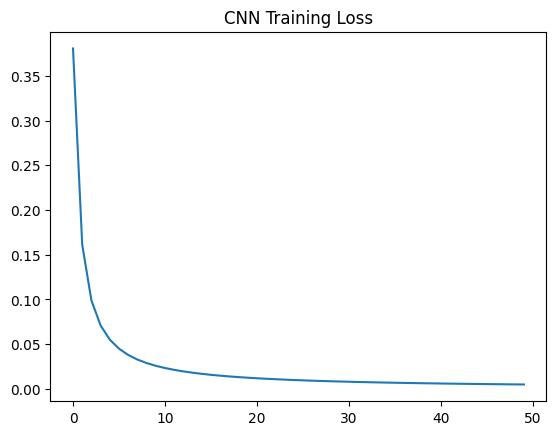

In [33]:
plt.plot(cnn_loss_curve)
plt.title("CNN Training Loss")
plt.show()


## Analysis

Which model generalises better?
The CNN generalises better by exploiting spatial structure that the dense model ignores.


Does pooling improve test performance?
Yes. Max pooling introduces translation invariance and reduces spatial resolution,
which curbs overfitting and makes the network more robust to small positional shifts.


Does dropout reduce the gap between validation and test performance?
Yes. Dropout prevents neurons from depending too heavily on one another,
leading to more generalisable representations.


How does parameter count relate to test accuracy?
Higher parameter counts raise model capacity but increase the risk of overfitting.
CNNs reach good accuracy with fewer parameters because filters are shared spatially.


Does the CNN scale better as image size grows?
Yes. Convolutional filter counts stay fixed regardless of image resolution,
whereas fully-connected networks grow quadratically with input size.


In [34]:
def init_adam_state(params):
    first_moment  = {}
    second_moment = {}
    for key in params:
        first_moment[key]  = np.zeros_like(params[key])
        second_moment[key] = np.zeros_like(params[key])
    return first_moment, second_moment


In [35]:
def adam_step(params, grads, m1, m2, t, lr=0.001, beta1=0.9, beta2=0.999, eps=1e-8):
    for key in params:
        m1[key] = beta1 * m1[key] + (1 - beta1) * grads[key]
        m2[key] = beta2 * m2[key] + (1 - beta2) * (grads[key] ** 2)
        m1_hat  = m1[key] / (1 - beta1 ** t)
        m2_hat  = m2[key] / (1 - beta2 ** t)
        params[key] -= lr * m1_hat / (np.sqrt(m2_hat) + eps)
    return params, m1, m2


In [36]:
def total_grad_norm(grads):
    total = 0
    for g in grads.values():
        total += np.sum(g ** 2)
    return np.sqrt(total)


In [37]:
def train_cnn_with_optimizer(X_data, y_data, optimizer="sgd", num_epochs=50, lr=0.01):
    global filter_bank, W_fc, b_fc
    losses = []
    g_norms = []
    fc_params = {"W": W_fc, "b": b_fc}
    m1, m2 = init_adam_state(fc_params)
    step = 1

    for ep in range(num_epochs):
        ep_loss = 0
        for idx in range(len(X_data)):
            img   = X_data[idx]
            label = y_data[idx]
            y_hat, flat = cnn_predict(img, filter_bank, W_fc, b_fc)
            loss = binary_cross_entropy(label, y_hat)
            dz   = y_hat - label
            g = {"W": flat.T @ dz, "b": dz}
            g_norms.append(total_grad_norm(g))

            if optimizer == "sgd":
                fc_params["W"] -= lr * g["W"]
                fc_params["b"] -= lr * g["b"]
            elif optimizer == "adam":
                fc_params, m1, m2 = adam_step(fc_params, g, m1, m2, step, lr)

            step += 1
            ep_loss += loss

        losses.append(ep_loss / len(X_data))

    return losses, g_norms


In [38]:
sgd_losses, sgd_gnorms = train_cnn_with_optimizer(
    X_train_img, y_train_img,
    optimizer="sgd",
    num_epochs=50
)


In [39]:
adam_losses, adam_gnorms = train_cnn_with_optimizer(
    X_train_img, y_train_img,
    optimizer="adam",
    num_epochs=50
)


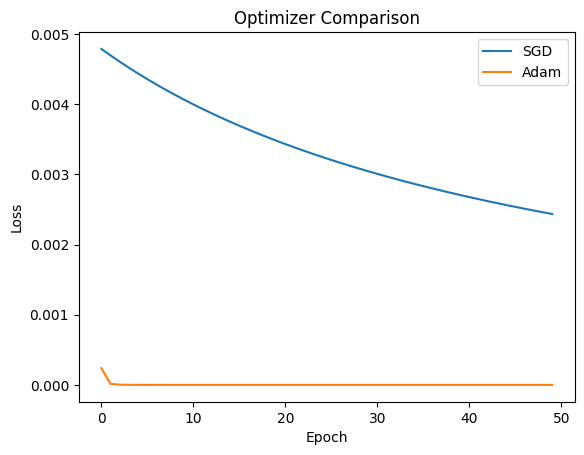

In [40]:
plt.plot(sgd_losses,  label="SGD")
plt.plot(adam_losses, label="Adam")
plt.legend()
plt.title("Optimizer Comparison")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()


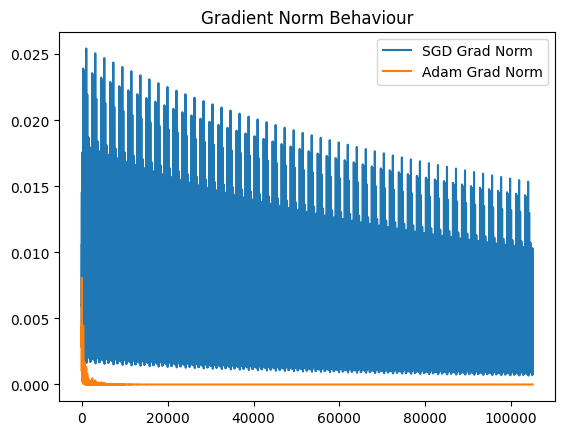

In [41]:
plt.plot(sgd_gnorms,  label="SGD Grad Norm")
plt.plot(adam_gnorms, label="Adam Grad Norm")
plt.legend()
plt.title("Gradient Norm Behaviour")
plt.show()


In [42]:
num_correct = 0
for idx in range(len(X_test_img)):
    pred, _ = cnn_predict(X_test_img[idx], filter_bank, W_fc, b_fc)
    if (pred >= 0.5) == y_test_img[idx]:
        num_correct += 1

print("CNN Test Accuracy:", num_correct / len(X_test_img))


CNN Test Accuracy: 1.0


## Final Reflection

Where did training fail because of architectural structure?
Deep sigmoid networks failed to train effectively. Repeated multiplication by small
sigmoid derivatives caused gradients to shrink to near zero across many layers,
leaving early weights essentially unchanged.


Where did the optimizer matter more than the activation?
In deep architectures, plain SGD struggled to make consistent progress.
Momentum and Adam reduced oscillation and maintained gradient flow,
leading to noticeably faster and more reliable convergence.


Where did activation matter more than depth?
At comparable depths, ReLU networks learned faster and more stably than sigmoid ones.
The unbounded derivative of ReLU avoids gradient saturation in a way sigmoid cannot match.


What causes gradients to shrink across layers?
Each backward pass multiplies incoming gradients by the local activation derivative.
When that derivative is consistently less than 1 (as with sigmoid), the product
across many layers decays exponentially toward zero.


Why does the CNN generalise better than a fully-connected network on image data?
Convolutional filters learn local spatial patterns and share those parameters across
the entire image. This structural prior dramatically reduces the number of parameters
while preserving the spatial relationships that matter for classification.


Why does dropout reduce overfitting?
By randomly zeroing out neurons during each training step, dropout forces the network
to rely on redundant pathways rather than memorising specific co-activation patterns.


When does depth hurt test performance?
When a model is deeper than the problem complexity warrants, it overfits the training
set and gradient signals degrade before reaching earlier layers -- both reduce generalisation.


Did validation performance reliably track test performance?
Mostly yes, but not always perfectly. Differences in data sampling and implicit
tuning pressure on the validation set can cause the two metrics to diverge slightly.
